In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── 1. LOAD DATA ─────────────────────────────────────────────────────────────
cancellation = pd.read_csv("cancellation.csv")
subscription = pd.read_csv("subscription_v2.csv", sep=";")

# ── 2. PRE-MERGE CLEANING ───────────────────────────────────────────────────
cancellation['expiration_date'] = pd.to_datetime(cancellation['expiration_date'], errors='coerce')
subscription['subscription_cancel_date'] = pd.to_datetime(subscription['subscription_cancel_date'], dayfirst=True, errors='coerce')

# Behold kun seneste record pr. kunde for at undgå dubletter i merge
cancellation = cancellation.sort_values('expiration_date', ascending=False).drop_duplicates('pseudo_id')
subscription = subscription.sort_values('subscription_cancel_date', ascending=False).drop_duplicates('pseudo_id')

# ── 3. MERGE ─────────────────────────────────────────────────────────────────
df = pd.merge(subscription, cancellation, on="pseudo_id", how="left")

# ── 4. DATE PARSING ──────────────────────────────────────────────────────────
date_cols_dmy = ["first_campaign_day", "last_campaign_day", "usr_created", "birthdate"]
for col in date_cols_dmy:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")

df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# ── 5. CHURN LOGIC (TARGET) ──────────────────────────────────────────────────
df['churn'] = 0
mask_churn = (df['expiration_date'].notna()) & (df['expiration_date'] <= df['last_campaign_day'])
df.loc[mask_churn, 'churn'] = 1


# ── 6. CLEANING & FEATURE ENGINEERING ────────────────────────────────────────
df = df.dropna(subset=['birthdate', 'usr_created', 'order_date'])

# Håndtering af manglende værdier
df['koen'] = df['koen'].replace(["", " "], np.nan).fillna("Ikke oplyst")

# Permissions til 1/0
df['permission_given_order'] = df['permission_given_order'].apply(lambda x: 1 if str(x).lower() == "true" else 0)
df['permission_given_today'] = df['permission_given_today'].apply(lambda x: 1 if str(x).lower() == "true" else 0)

# Beregn alder og kundetid (Numeriske variable)
today = pd.Timestamp.now()
df['age'] = (today - df['birthdate']).dt.days / 365.25
df['kundetid_dage'] = (df['order_date'] - df['usr_created']).dt.days
df = df[df['kundetid_dage'] >= 0]

# ── 7. SELEKTION AF FEATURES (X) OG TARGET (y) ──────────────────────────────
# Vi fjerner datoer og ID'er, som ikke kan bruges direkte i matematikken.

target_col = 'churn'
quant_cols = ['account_active_days', 'age', 'kundetid_dage', 'previous_subscriptions', 'previous_campaigns',
              'previous_trials', 'newsletters_before_order', 'newsletters_after_order']
cat_cols = ['koen', 'permission_given_order', 'permission_given_today']

# Opret Y
y = df[target_col].values

# Opret X med One-Hot Encoding (Dummies)
# Vi bruger drop_first=False som i lærerens eksempel for Neuralt Netværk
X_cat_dummies = pd.get_dummies(df[cat_cols], drop_first=False)
X_df = pd.concat([df[quant_cols], X_cat_dummies], axis=1)

# ── 8. SPLIT OG SKALERING (Lærerens metode) ──────────────────────────────────
# Opdel i 80/20
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y, test_size=0.20, random_state=8, stratify=y
)

# Standardisér KUN de kvantitative (numeriske) kolonner
# Dette er afgørende for at det neurale netværk kan lære effektivt

scaler = StandardScaler()
X_train_arr = X_train_df.copy()
X_test_arr = X_test_df.copy()

X_train_arr[quant_cols] = scaler.fit_transform(X_train_df[quant_cols])
X_test_arr[quant_cols] = scaler.transform(X_test_df[quant_cols])

# Konvertér til float32 arrays (Det format Keras kræver)
X_train = X_train_arr.values.astype(np.float32)
X_test = X_test_arr.values.astype(np.float32)

# ── 9. KONTROL ───────────────────────────────────────────────────────────────
print(f"X_train form: {X_train.shape} (Antal rækker, Antal features)")
print(f"Churn rate i træningssæt: {y_train.mean():.2%}")
print("\nFærdig til brug i Sequential model!")

X_train form: (1013, 13) (Antal rækker, Antal features)
Churn rate i træningssæt: 41.86%
<class 'pandas.core.frame.DataFrame'>
Index: 1267 entries, 0 to 1278
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   pseudo_id                 1267 non-null   object        
 1   account_active_days       1267 non-null   int64         
 2   subscription_cancel_date  1050 non-null   datetime64[ns]
 3   order_date                1267 non-null   datetime64[ns]
 4   koen                      1267 non-null   object        
 5   birthdate                 1267 non-null   datetime64[ns]
 6   usr_created               1267 non-null   datetime64[ns]
 7   order_trackertag          1261 non-null   object        
 8   permission_given_order    1267 non-null   int64         
 9   permission_given_today    1267 non-null   int64         
 10  previous_subscriptions    1267 non-null   int64         
 11

In [5]:
# model_01
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K, callbacks, regularizers

K.clear_session()
tf.random.set_seed(8)

# ── 2. BUILD MODEL 01 ────────────────────────────────────────────────────────
# X_train.shape[1] automatically knows how many features you have from before
model_01 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
], name="baseline_nn")

model_01.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# ── 3. TRAINING ──────────────────────────────────────────────────────────────
# Using y_train and X_train directly from your previous script execution
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Model 01 (Baseline)...")
history_01 = model_01.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

# ── 4. EVALUATE ──────────────────────────────────────────────────────────────
# Using X_test and y_test from your previous script execution
metrics_01 = model_01.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*30)
print(f"Model 01 TEST AUC: {metrics_01[2]:.4f}")
print(f"Model 01 TEST ACC: {metrics_01[1]:.4f}")
print("="*30)

Training Model 01 (Baseline)...
Epoch 1/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5407 - auc: 0.5012 - loss: 0.7668 - val_accuracy: 0.5961 - val_auc: 0.6608 - val_loss: 0.7160
Epoch 2/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6086 - auc: 0.6005 - loss: 0.7321 - val_accuracy: 0.5961 - val_auc: 0.6574 - val_loss: 0.7091
Epoch 3/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6074 - auc: 0.6064 - loss: 0.7287 - val_accuracy: 0.6207 - val_auc: 0.6598 - val_loss: 0.7053
Epoch 4/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6259 - auc: 0.6583 - loss: 0.7049 - val_accuracy: 0.6256 - val_auc: 0.6614 - val_loss: 0.7017
Epoch 5/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6284 - auc: 0.6610 - loss: 0.7037 - val_accuracy: 0.6305 - val_auc: 0.6666 - val_loss: 0.6988
Epoch 6/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6210 - auc: 0.6622 - loss: 0.7080 - val_accuracy: 0.6453 - val_auc: 0.6703 - val_loss: 0.6931
Epoch 7/150
2

In [6]:
# model_02
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K, callbacks, regularizers

K.clear_session()
tf.random.set_seed(8)

# ── 2. BUILD THE DEEP MODEL (Complex Architecture) ───────────────────────────
model_02 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    # Layer 1: Wide initial layer + BatchNormalization
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.002)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Layer 2: Medium layer
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.002)),
    layers.Dropout(0.3),

    # Layer 3: Final refinement
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    # Output layer
    layers.Dense(1, activation="sigmoid")
], name="complex_nn_model")

# Using a custom learning rate as per your Model 02 setup
model_02.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.Recall(name="recall")]
)

# ── 3. ADVANCED CALLBACKS ────────────────────────────────────────────────────
# These help the model navigate complex loss landscapes
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

# ── 4. TRAIN ─────────────────────────────────────────────────────────────────
print("Training Model 02 (Complex NN)...")
history_02 = model_02.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ── 5. EVALUATE ──────────────────────────────────────────────────────────────
metrics_02 = model_02.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*40)
print(f"Model 02 TEST AUC:      {metrics_02[2]:.4f}")
print(f"Model 02 TEST RECALL:   {metrics_02[3]:.4f}")
print(f"Model 02 TEST ACC:      {metrics_02[1]:.4f}")
print("="*40)

Training Model 02 (Complex NN)...
Epoch 1/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5827 - auc: 0.5717 - loss: 0.9723 - recall: 0.3754 - val_accuracy: 0.5813 - val_auc: 0.6274 - val_loss: 0.9006 - val_recall: 0.6627 - learning_rate: 0.0010
Epoch 2/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5778 - auc: 0.6081 - loss: 0.9104 - recall: 0.4457 - val_accuracy: 0.6404 - val_auc: 0.6484 - val_loss: 0.8913 - val_recall: 0.5904 - learning_rate: 0.0010
Epoch 3/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6272 - auc: 0.6540 - loss: 0.8720 - recall: 0.4868 - val_accuracy: 0.6502 - val_auc: 0.6843 - val_loss: 0.8834 - val_recall: 0.5542 - learning_rate: 0.0010
Epoch 4/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6272 - auc: 0.6596 - loss: 0.8557 - recall: 0.5073 - val_accuracy: 0.6207 - val_auc: 0.6814 - val_loss: 0.8791 - val_recall: 0.6265 - learning_rate: 0.0010
Epoch 5/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6333 - auc: 0.67

In [7]:
# model_03
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras import layers, callbacks, regularizers, backend as K

K.clear_session()
tf.random.set_seed(8)

# ── 2. APPLY SMOTE (Balancing the Training Set) ──────────────────────────────
# We use X_train and y_train that were already prepped and scaled
# in your cleaning script.
sm = SMOTE(random_state=8)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original shape: {X_train.shape}")
print(f"Resampled shape (SMOTE): {X_train_res.shape}")

# ── 3. BUILD MODEL 03 (Architecture matching your R-style setup) ──────────────
model_03 = tf.keras.Sequential([
    layers.Input(shape=(X_train_res.shape[1],)),

    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.1),

    layers.Dense(1, activation="sigmoid")
], name="nn_smote_balanced")

model_03.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# ── 4. TRAINING ──────────────────────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

print("Training Model 03 (SMOTE Balanced)...")
history_03 = model_03.fit(
    X_train_res, y_train_res,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test), # Validate on the original, un-SMOTEd test data
    callbacks=[early_stop],
    verbose=1
)

# ── 5. EVALUATION ────────────────────────────────────────────────────────────
results_03 = model_03.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*35)
print(f"MODEL 03 TEST AUC:      {results_03[2]:.4f}")
print(f"MODEL 03 TEST ACCURACY: {results_03[1]:.4f}")
print("="*35)

Original shape: (1013, 13)
Resampled shape (SMOTE): (1178, 13)
Training Model 03 (SMOTE Balanced)...
Epoch 1/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5280 - auc: 0.5575 - loss: 0.7112 - val_accuracy: 0.6063 - val_auc: 0.6313 - val_loss: 0.6843
Epoch 2/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5739 - auc: 0.6001 - loss: 0.6951 - val_accuracy: 0.6457 - val_auc: 0.6906 - val_loss: 0.6718
Epoch 3/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6197 - auc: 0.6532 - loss: 0.6793 - val_accuracy: 0.6732 - val_auc: 0.7252 - val_loss: 0.6610
Epoch 4/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6265 - auc: 0.6691 - loss: 0.6706 - val_accuracy: 0.6890 - val_auc: 0.7417 - val_loss: 0.6535
Epoch 5/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6562 - auc: 0.6901 - loss: 0.6654 - val_accuracy: 0.6969 - val_auc: 0.7495 - val_loss: 0.6421
Epoch 6/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6443 - auc: 0.7042 - loss: 0.6524 - val

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


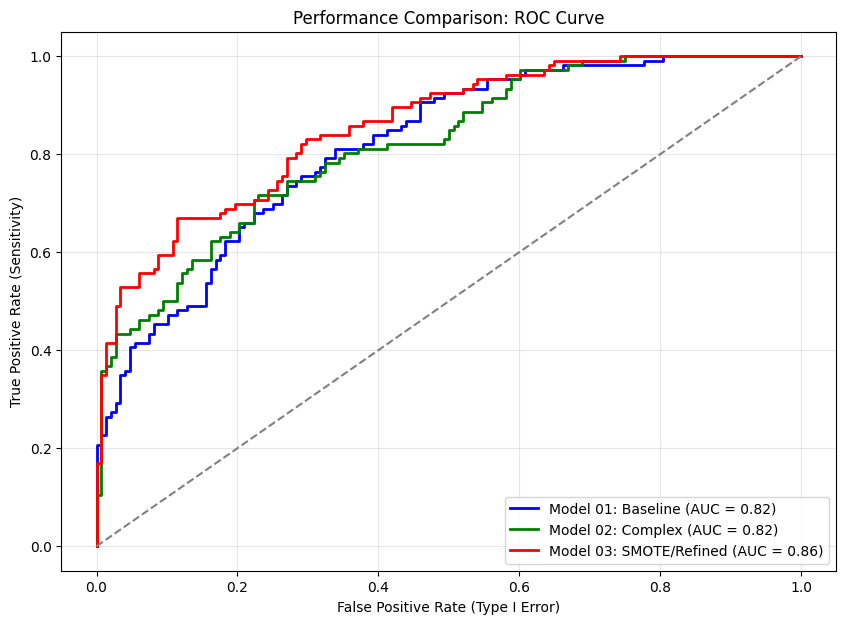

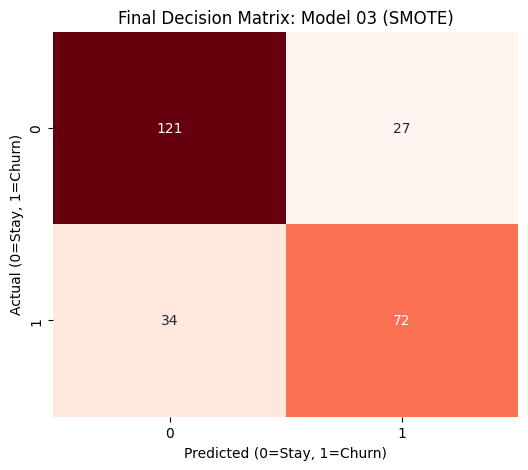


--- Model Performance Leaderboard ---
              Model   AUC  Recall (Churn Caught)  Accuracy
   Model 03 (SMOTE) 0.857                  0.679     0.760
 Model 02 (Complex) 0.819                  0.679     0.736
Model 01 (Baseline) 0.817                  0.689     0.724


In [8]:
# ── VISUALISATION: MODEL COMPARISON ──────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, recall_score, accuracy_score

# 1. GENERATE PREDICTIONS
# All models now use the same X_test prepared in your cleaning script
probs_01 = model_01.predict(X_test)
probs_02 = model_02.predict(X_test)
probs_03 = model_03.predict(X_test)

preds_03 = (probs_03 > 0.5).astype(int)

# 2. CREATE A 3-WAY ROC COMPARISON
plt.figure(figsize=(10, 7))

# Helper list for plotting
model_data = [
    (probs_01, 'Model 01: Baseline', 'blue'),
    (probs_02, 'Model 02: Complex', 'green'),
    (probs_03, 'Model 03: SMOTE/Refined', 'red')
]

for probs, label, color in model_data:
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate (Type I Error)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Performance Comparison: ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 3. FINAL CONFUSION MATRIX (Focusing on Model 03)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, preds_03)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Final Decision Matrix: Model 03 (SMOTE)')
plt.xlabel('Predicted (0=Stay, 1=Churn)')
plt.ylabel('Actual (0=Stay, 1=Churn)')
plt.show()

# 4. THE "LEADERBOARD" TABLE
results = []
for m_name, m_probs in [
    ("Model 01 (Baseline)", probs_01),
    ("Model 02 (Complex)",  probs_02),
    ("Model 03 (SMOTE)",    probs_03)
]:
    m_preds = (m_probs > 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_test, m_probs)

    results.append({
        "Model": m_name,
        "AUC": round(auc(fpr, tpr), 3),
        "Recall (Churn Caught)": round(recall_score(y_test, m_preds), 3),
        "Accuracy": round(accuracy_score(y_test, m_preds), 3)
    })

print("\n--- Model Performance Leaderboard ---")
print(pd.DataFrame(results).sort_values(by="AUC", ascending=False).to_string(index=False))